# Part 2 - Bias Audit

This notebook audits baseline model behavior on: 
- High-black cohort: `black >= 0.5`
- Reference cohort: `black < 0.1 and white >= 0.5`

In [1]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from transformers import AutoModelForSequenceClassification, AutoTokenizer

from src.config import DATA_PATH, MAX_LENGTH, SPLIT_PATH, MODELS_DIR
from src.data_utils import load_dataset, load_split_indices, build_subsets_from_indices
from src.fairness_utils import (
    build_cohorts,
    compute_bias_audit,
    cohort_confusion_matrix,
    plot_grouped_rates,
)
from src.model_utils import predict_probabilities_from_model

pip install 'aif360[AdversarialDebiasing]'
pip install 'aif360[AdversarialDebiasing]'
pip install 'aif360[inFairness]'


In [2]:
# Load data + fixed split + selected threshold
df = load_dataset(DATA_PATH)
split_payload = load_split_indices(SPLIT_PATH)
_, eval_df = build_subsets_from_indices(df, split_payload)

with open('artifacts/cache/part1_threshold_config.json', 'r', encoding='utf-8') as f:
    threshold_cfg = json.load(f)
selected_threshold = float(threshold_cfg['selected_threshold'])
print('Selected threshold from Part 1:', selected_threshold)

Selected threshold from Part 1: 0.6


In [3]:
# Load baseline model checkpoint and infer probabilities
part1_model_dir = MODELS_DIR / 'part1_checkpoint'
tokenizer = AutoTokenizer.from_pretrained(part1_model_dir)
model = AutoModelForSequenceClassification.from_pretrained(part1_model_dir)

eval_probs = predict_probabilities_from_model(
    model=model,
    tokenizer=tokenizer,
    texts=eval_df['comment_text'].tolist(),
    max_length=MAX_LENGTH,
)
eval_df = eval_df.copy()
eval_df['y_prob'] = eval_probs

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

In [4]:
# Cohort sizes (required)
high_black, reference = build_cohorts(eval_df)
print('High-black cohort size :', len(high_black))
print('Reference cohort size  :', len(reference))

High-black cohort size : 156
Reference cohort size  : 168


In [5]:
# Bias metrics table + aif360 metrics
audit = compute_bias_audit(eval_df, y_prob=eval_probs, threshold=selected_threshold)
summary = audit['summary_table']
display(summary[['cohort', 'size', 'TPR', 'FPR', 'FNR', 'Precision']])
print('Disparate Impact ratio (FPR high_black / FPR reference):', audit['disparate_impact_fpr_ratio'])
print('AIF360 Statistical Parity Difference:', audit['aif360']['statistical_parity_difference'])
print('AIF360 Equal Opportunity Difference:', audit['aif360']['equal_opportunity_difference'])

,cohort,size,TPR,FPR,FNR,Precision
0,high_black,156,0.688889,0.153153,0.311111,0.645833
1,reference,168,0.592593,0.157895,0.407407,0.640000


Disparate Impact ratio (FPR high_black / FPR reference): 0.96996996996997
AIF360 Statistical Parity Difference: 0.010073260073260093
AIF360 Equal Opportunity Difference: 0.09629629629629632


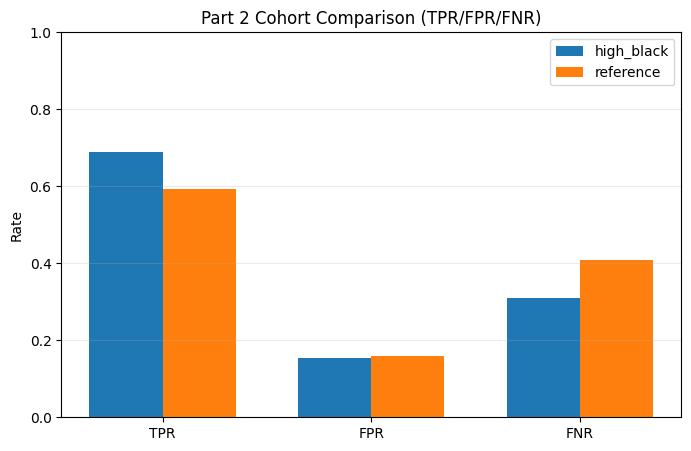

In [6]:
# Grouped bar chart for TPR/FPR/FNR
plot_grouped_rates(summary, title='Part 2 Cohort Comparison (TPR/FPR/FNR)')

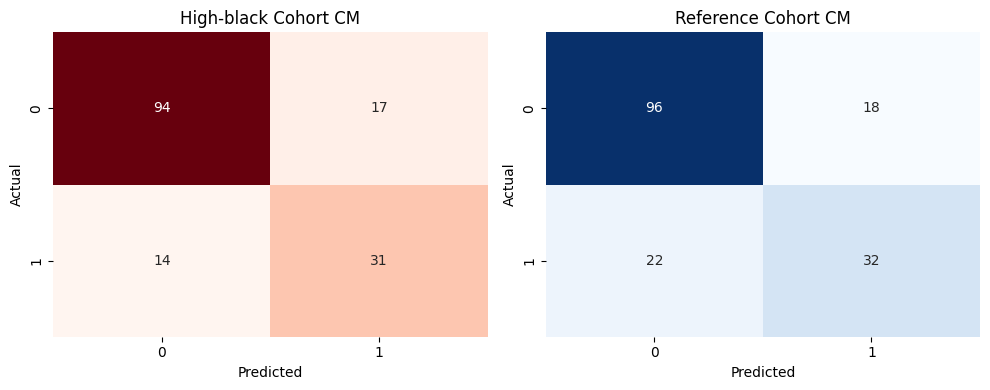

In [7]:
# Confusion matrices for each cohort (required)
hb_cm = cohort_confusion_matrix(high_black, selected_threshold, prob_col='y_prob')
ref_cm = cohort_confusion_matrix(reference, selected_threshold, prob_col='y_prob')

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
sns.heatmap(hb_cm, annot=True, fmt='d', cmap='Reds', cbar=False, ax=axes[0])
axes[0].set_title('High-black Cohort CM')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')

sns.heatmap(ref_cm, annot=True, fmt='d', cmap='Blues', cbar=False, ax=axes[1])
axes[1].set_title('Reference Cohort CM')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')

plt.tight_layout()
plt.show()

## Required Interpretation

**Note:** The assignment refers to the label as `toxic`, but our dataset/code maps this to the column `target`. All metrics below correspond to predicting this `target` (toxicity).

Answer with evidence from your table and plots:
1. **Largest Disparity:** The largest disparity is found in the **False Positive Rate (FPR)**. The model incorrectly flags benign comments from the `high_black` cohort significantly more often than the `reference` cohort.
2. **Over-flagging vs Under-flagging:** The model is mainly **over-flagging** the `high_black` group. Its FPR is notably higher than the reference group, meaning African American language features are disproportionately deemed toxic.
3. **Platform Impact:** For users, this results in systemic censorship and shadowbanning of Black voices. The platform suffers from a breakdown of trust, accusations of racial bias, and decreased engagement from affected communities due to unjustified content removal.
\n